In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, LearningRateScheduler
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import pandas as pd
import os
from tensorflow.keras.utils import img_to_array, load_img
import json
from pycocotools.coco import COCO
import matplotlib.pyplot as plt
from PIL import Image
import cv2
from skimage.draw import polygon
from concurrent.futures import ThreadPoolExecutor
from tensorflow.keras.layers import Dropout
from sklearn.metrics import precision_score, recall_score, confusion_matrix, f1_score
from sklearn.metrics import confusion_matrix
import seaborn as sns
from tensorflow.keras import layers, models
import albumentations as A


In [ ]:
# Set paths
train_image_dir = '/content/drive/MyDrive/archive/train'
train_mask_path = '/content/drive/MyDrive/archive/train/_annotations.coco.json'
val_image_dir = '/content/drive/MyDrive/archive/valid'
val_mask_path = '/content/drive/MyDrive/archive/valid/_annotations.coco.json'
test_image_dir = '/content/drive/MyDrive/archive/test'
test_mask_path = '/content/drive/MyDrive/archive/test/_annotations.coco.json'


In [ ]:
IMG_HEIGHT = 128
IMG_WIDTH = 128
input_size = (128, 128, 3)
batch_size = 16
learning_rate = 1e-4

Total number of image files in /content/drive/MyDrive/archive/test: 215
Total number of image files in /content/drive/MyDrive/archive/train: 1502
Total number of image files in /content/drive/MyDrive/archive/valid: 429


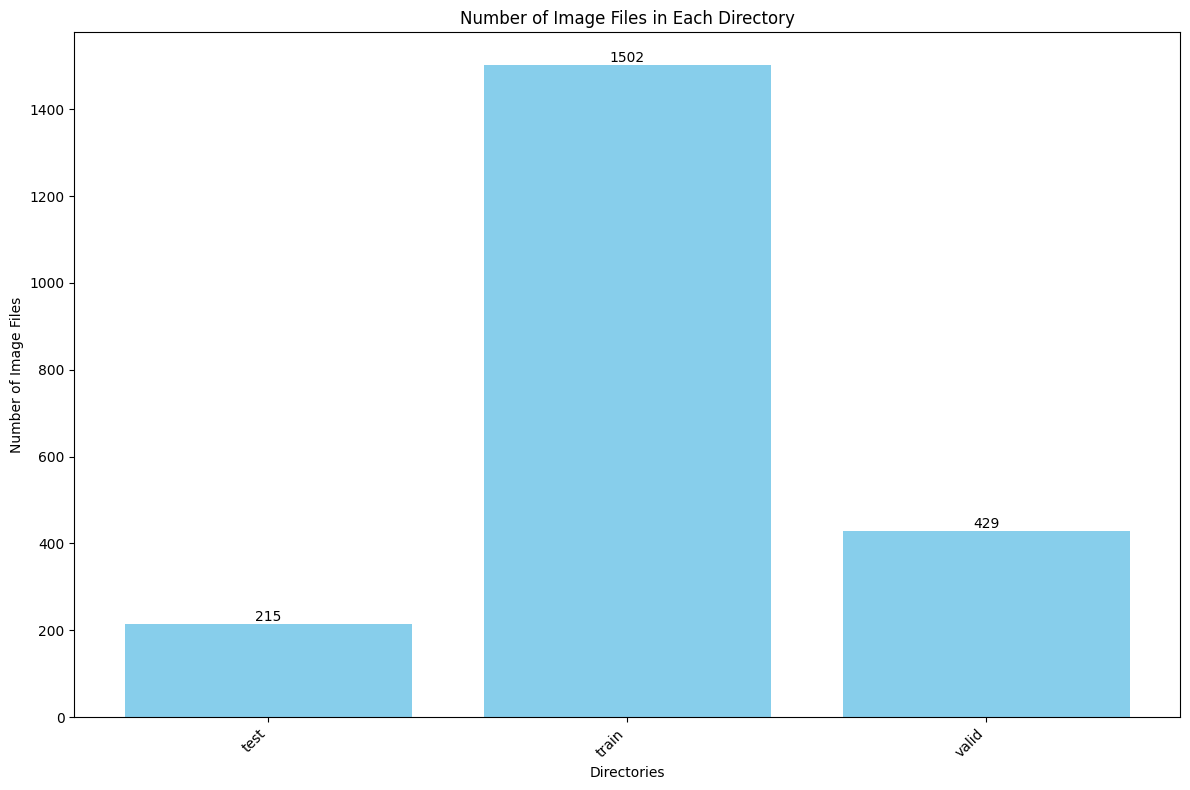

In [ ]:

# Function to count image files in a directory
def count_image_files(directory):
    # Supported image extensions
    image_extensions = ['.png', '.jpg', '.jpeg', '.gif', '.bmp', '.tiff']

    # Dictionary to store count of each type
    image_count = {ext: 0 for ext in image_extensions}
    total_images = 0

    # Walk through directory
    for root, dirs, files in os.walk(directory):
        for file in files:
            # Get file extension
            ext = os.path.splitext(file)[1].lower()
            if ext in image_extensions:
                image_count[ext] += 1
                total_images += 1

    return total_images

# Function to plot the image counts
def plot_image_counts(image_counts, directory_names):
    plt.figure(figsize=(12, 8))
    bars = plt.bar(directory_names, image_counts, color='skyblue')
    plt.xlabel('Directories')
    plt.ylabel('Number of Image Files')
    plt.title('Number of Image Files in Each Directory')
    plt.xticks(rotation=45, ha='right')
    # Add counts above the bars
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2.0, yval, int(yval), ha='center', va='bottom')
    plt.tight_layout()
    plt.show()

# List of directories
directories = [
    '/content/drive/MyDrive/archive/test',
    '/content/drive/MyDrive/archive/train',
    '/content/drive/MyDrive/archive/valid'
]

# Get directory names from paths
directory_names = [os.path.basename(directory) for directory in directories]

# Count image files in each directory
image_counts = []
for directory in directories:
    image_count = count_image_files(directory)
    image_counts.append(image_count)
    print(f"Total number of image files in {directory}: {image_count}")

# Plot the results
plot_image_counts(image_counts, directory_names)


In [ ]:
def create_mask_from_annotations(annotations, height, width):
    mask = np.zeros((height, width), dtype=np.uint8)
    for annotation in annotations:
        for seg in annotation['segmentation']:
            poly = np.array(seg).reshape((len(seg) // 2, 2))
            rr, cc = polygon(poly[:, 1], poly[:, 0], (height, width))
            mask[rr, cc] = 1
    return mask

def process_image(img_info, image_dir, coco):
    img_path = os.path.join(image_dir, img_info['file_name'])
    img = cv2.imread(img_path)
    if img is None:
        print(f"Warning: Unable to read image at {img_path}")
        return None, None

    img = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT))
    img = img / 255.0

    ann_ids = coco.getAnnIds(imgIds=img_info['id'])
    annotations = coco.loadAnns(ann_ids)

    mask = create_mask_from_annotations(annotations, img_info['height'], img_info['width'])
    mask = cv2.resize(mask, (IMG_WIDTH, IMG_HEIGHT))
    mask = mask / 255.0

    mask = cv2.resize(mask, (IMG_WIDTH, IMG_HEIGHT))
    mask = (mask > 0).astype(np.float32)

    return img, mask

def load_images_and_masks(image_dir, mask_path, img_height=IMG_HEIGHT, img_width=IMG_WIDTH):
    coco = COCO(mask_path)
    images = []
    masks = []

    img_ids = coco.getImgIds()
    img_infos = coco.loadImgs(img_ids)

    # Use ThreadPoolExecutor to process images in parallel
    with ThreadPoolExecutor() as executor:
        results = list(executor.map(lambda img_info: process_image(img_info, image_dir, coco), img_infos))

    for img, mask in results:
        if img is not None and mask is not None:
            images.append(img)
            masks.append(mask)

    images = np.array(images)
    masks = np.array(masks)
    masks = np.expand_dims(masks, axis=-1)  # Add channel dimension

    return images, masks

def plot_image_and_mask(img, mask):
    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.title("Original Image")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(mask, cmap='gray')
    plt.title("Segmented Mask")
    plt.axis('off')

    plt.show()

# Load annotations
train_image, train_mask = load_images_and_masks(train_image_dir, train_mask_path)
val_image, val_mask = load_images_and_masks(val_image_dir,val_mask_path)
test_image, test_mask = load_images_and_masks(test_image_dir, test_mask_path)

loading annotations into memory...
Done (t=0.04s)
creating index...
index created!
loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!


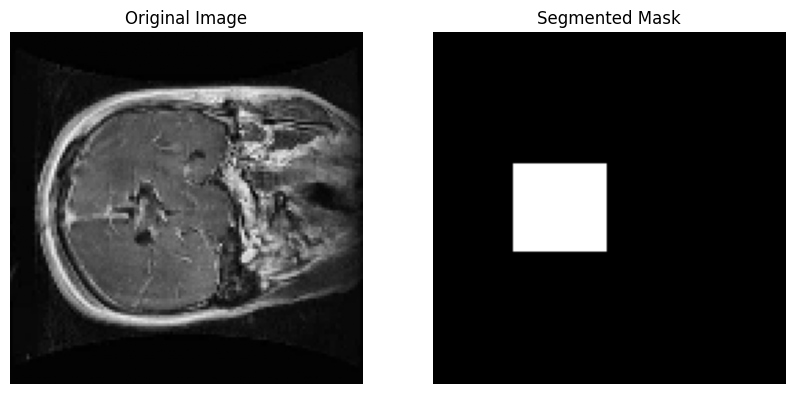

In [ ]:
sample_idx = 0  # Change index to plot different samples
plot_image_and_mask(train_image[sample_idx], train_mask[sample_idx])

In [ ]:
# Define the U-Net model
def unet_model(input_size=(256, 256, 3)):
    inputs = Input(input_size)

    # Encoder
    c1 = Conv2D(64, (3, 3), activation='relu', padding='same')(inputs)
    c1 = Conv2D(64, (3, 3), activation='relu', padding='same')(c1)
    p1 = MaxPooling2D((2, 2))(c1)

    c2 = Conv2D(128, (3, 3), activation='relu', padding='same')(p1)
    c2 = Conv2D(128, (3, 3), activation='relu', padding='same')(c2)
    p2 = MaxPooling2D((2, 2))(c2)

    c3 = Conv2D(256, (3, 3), activation='relu', padding='same')(p2)
    c3 = Conv2D(256, (3, 3), activation='relu', padding='same')(c3)
    p3 = MaxPooling2D((2, 2))(c3)

    c4 = Conv2D(512, (3, 3), activation='relu', padding='same')(p3)
    c4 = Conv2D(512, (3, 3), activation='relu', padding='same')(c4)
    p4 = MaxPooling2D((2, 2))(c4)

    # Bottleneck
    c5 = Conv2D(1024, (3, 3), activation='relu', padding='same')(p4)
    c5 = Dropout(0.5)(c5)  # Adding dropout
    c5 = Conv2D(1024, (3, 3), activation='relu', padding='same')(c5)

    # Decoder
    u6 = UpSampling2D((2, 2))(c5)
    u6 = concatenate([u6, c4])
    c6 = Conv2D(512, (3, 3), activation='relu', padding='same')(u6)
    c6 = Conv2D(512, (3, 3), activation='relu', padding='same')(c6)

    u7 = UpSampling2D((2, 2))(c6)
    u7 = concatenate([u7, c3])
    c7 = Conv2D(256, (3, 3), activation='relu', padding='same')(u7)
    c7 = Conv2D(256, (3, 3), activation='relu', padding='same')(c7)

    u8 = UpSampling2D((2, 2))(c7)
    u8 = concatenate([u8, c2])
    c8 = Conv2D(128, (3, 3), activation='relu', padding='same')(u8)
    c8 = Conv2D(128, (3, 3), activation='relu', padding='same')(c8)

    u9 = UpSampling2D((2, 2))(c8)
    u9 = concatenate([u9, c1])
    c9 = Conv2D(64, (3, 3), activation='relu', padding='same')(u9)
    c9 = Conv2D(64, (3, 3), activation='relu', padding='same')(c9)

    outputs = Conv2D(1, (1, 1), activation='sigmoid')(c9)

    model = Model(inputs=[inputs], outputs=[outputs])
    return model


In [ ]:
# Instantiate the model
UNETmodel = unet_model(input_size=input_size)

UNETmodel.summary()

# Compile the model
optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
UNETmodel.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 128, 128, 3)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d (Conv2D)           │ (None, 128, 128, 64)   │          1,792 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_1 (Conv2D)         │ (None, 128, 128, 64)   │         36,928 │ conv2d[0][0]           │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d             │ (None, 64, 64, 64)     │              0 │ conv2d_1[0][0]         │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_2 (Conv2D)         │ (None, 64, 64, 128)    │         73,856 │ max_pooling2d[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_3 (Conv2D)         │ (None, 64, 64, 128)    │        147,584 │ conv2d_2[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_1           │ (None, 32, 32, 128)    │              0 │ conv2d_3[0][0]         │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_4 (Conv2D)         │ (None, 32, 32, 256)    │        295,168 │ max_pooling2d_1[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_5 (Conv2D)         │ (None, 32, 32, 256)    │        590,080 │ conv2d_4[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_2           │ (None, 16, 16, 256)    │              0 │ conv2d_5[0][0]         │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_6 (Conv2D)         │ (None, 16, 16, 512)    │      1,180,160 │ max_pooling2d_2[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_7 (Conv2D)         │ (None, 16, 16, 512)    │      2,359,808 │ conv2d_6[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_3           │ (None, 8, 8, 512)      │              0 │ conv2d_7[0][0]         │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_8 (Conv2D)         │ (None, 8, 8, 1024)     │      4,719,616 │ max_pooling2d_3[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout (Dropout)         │ (None, 8, 8, 1024)     │              0 │ conv2d_8[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_9 (Conv2D)         │ (None, 8, 8, 1024)     │      9,438,208 │ dropout[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ up_sampling2d             │ (None, 16, 16, 1024)   │              0 │ conv2d_9[0][0]         │
│ (UpSampling2D)            │                        │                │                        │
├──────────────────────

 Total params: 31,378,945 (119.70 MB)

 Trainable params: 31,378,945 (119.70 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
model_checkpoint = ModelCheckpoint('unet_best_model.keras', save_best_only=True)

In [ ]:
UNethistory = UNETmodel.fit(
    train_image, train_mask,
    validation_data=(val_image, val_mask),
    epochs=30,
    callbacks=[early_stopping, model_checkpoint]
)

Epoch 1/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 160s 2s/step - accuracy: 0.9479 - loss: 0.4078 - val_accuracy: 0.9633 - val_loss: 0.1176
Epoch 2/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 73s 542ms/step - accuracy: 0.9636 - loss: 0.1096 - val_accuracy: 0.9633 - val_loss: 0.1144
Epoch 3/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 45s 633ms/step - accuracy: 0.9638 - loss: 0.1055 - val_accuracy: 0.9633 - val_loss: 0.1028
Epoch 4/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 34s 473ms/step - accuracy: 0.9635 - loss: 0.0999 - val_accuracy: 0.9633 - val_loss: 0.1031
Epoch 5/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 41s 475ms/step - accuracy: 0.9628 - loss: 0.0979 - val_accuracy: 0.9633 - val_loss: 0.1069
Epoch 6/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 46s 579ms/step - accuracy: 0.9634 - loss: 0.0919 - val_accuracy: 0.9633 - val_loss: 0.0888
Epoch 7/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 50s 767ms/step - accuracy: 0.9645 - loss: 0.0846 - val_accuracy: 0.9660 - val_loss: 0.0839
Epoch 8/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 30s 632ms/step - accuracy: 0.9692 - loss: 0.0799 - val_accura

In [ ]:
# evaluate on the test set
UNettest_loss, UNettest_accuracy = UNETmodel.evaluate(test_image, test_mask, verbose=1)
print(f"U-Net model Test Loss: {UNettest_loss}")
print(f"U-Net model Test Accuracy: {UNettest_accuracy}")

7/7 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - accuracy: 0.9805 - loss: 0.0530
U-Net model Test Loss: 0.051753852516412735
U-Net model Test Accuracy: 0.9808003306388855


7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 110ms/step


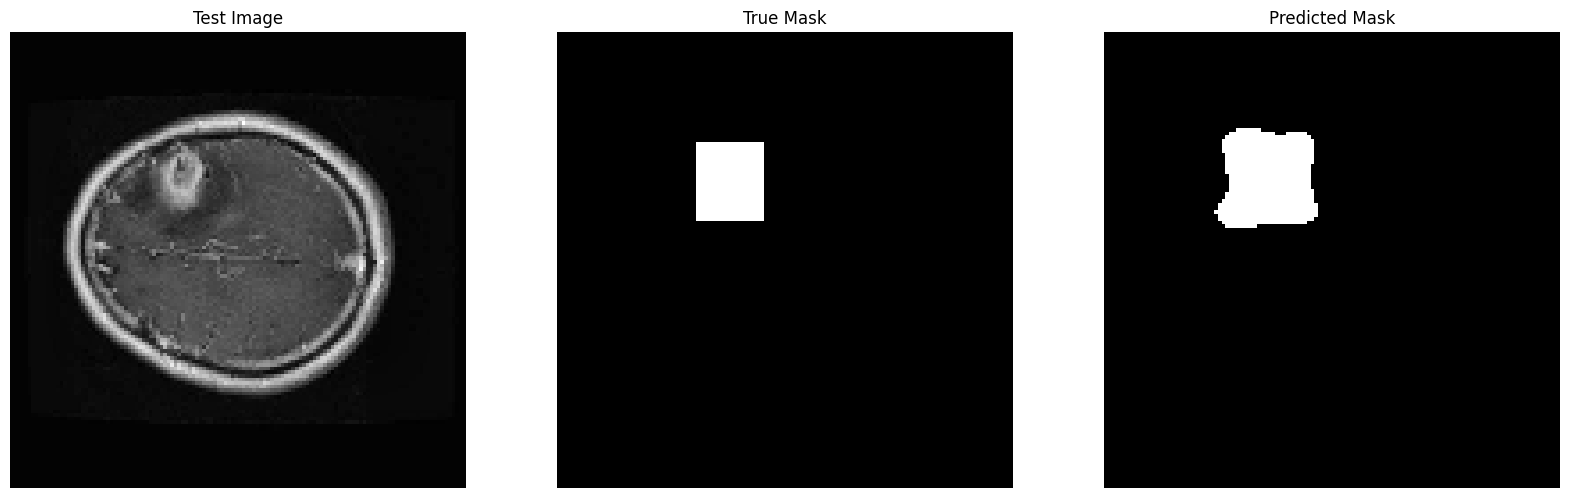

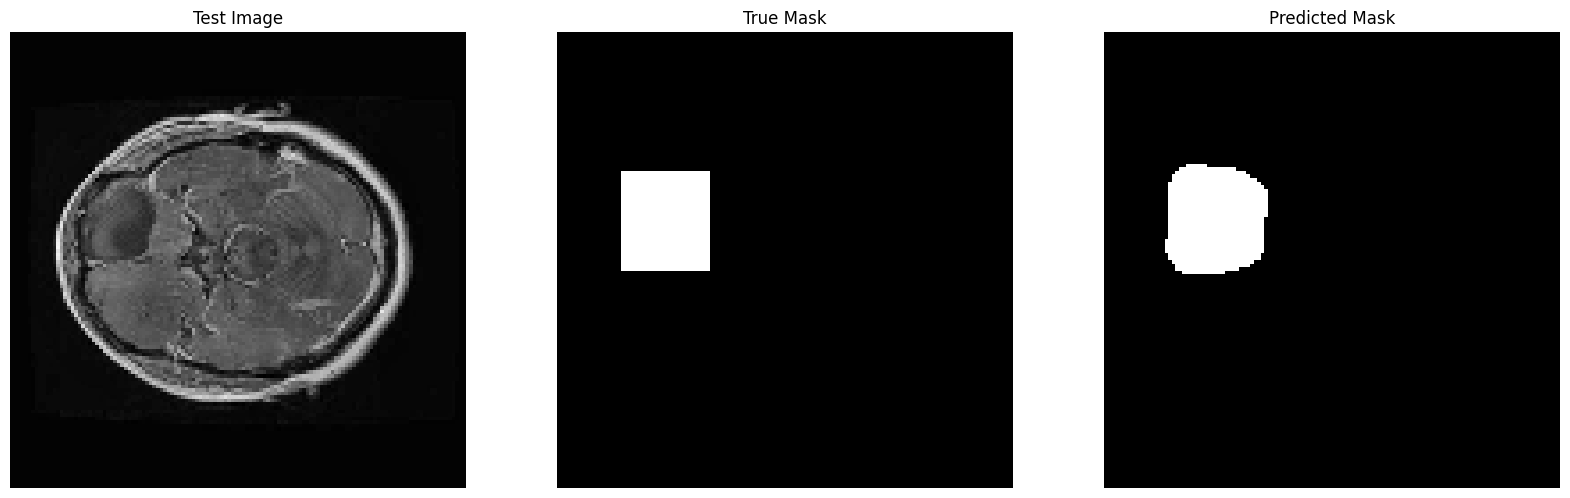

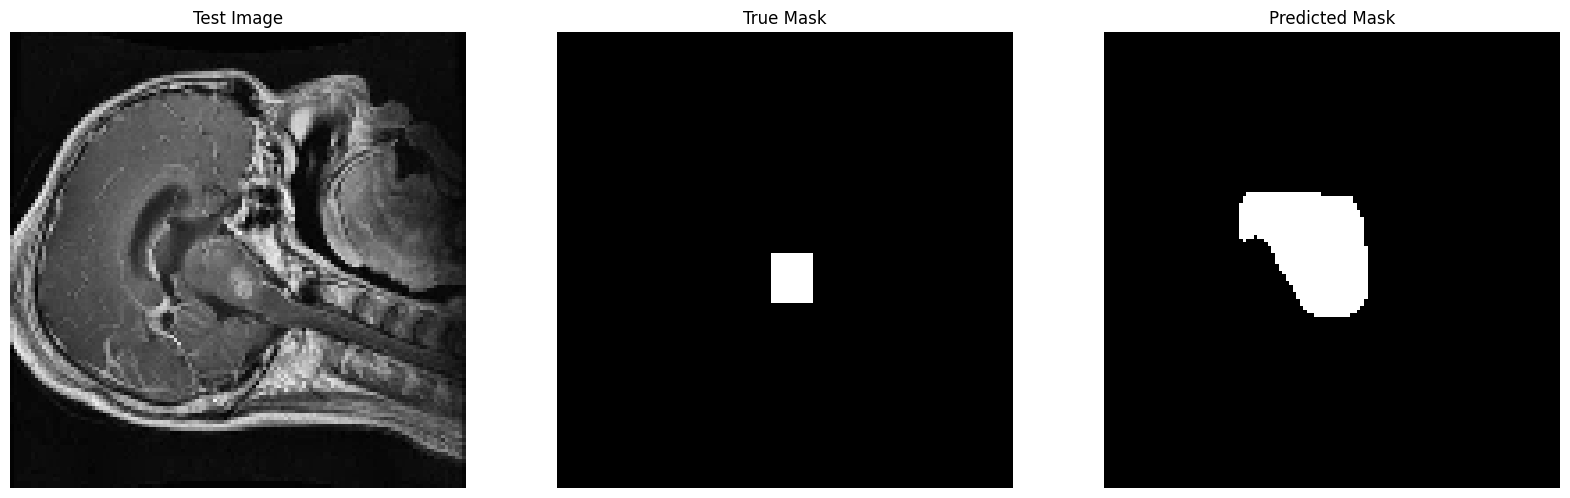

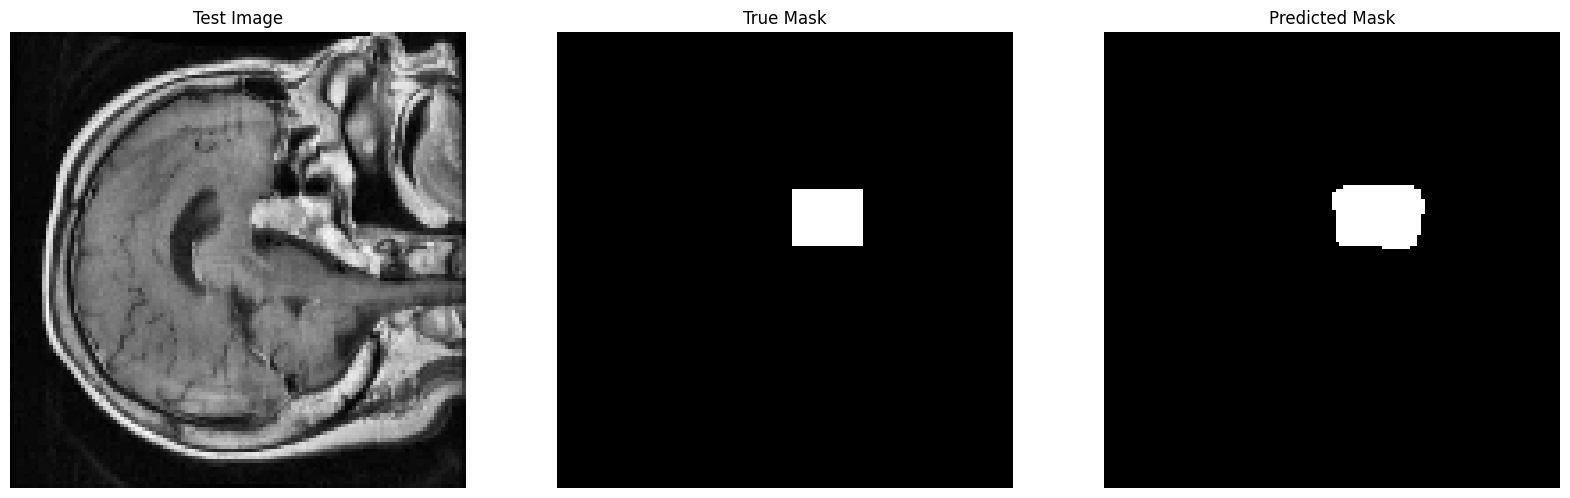

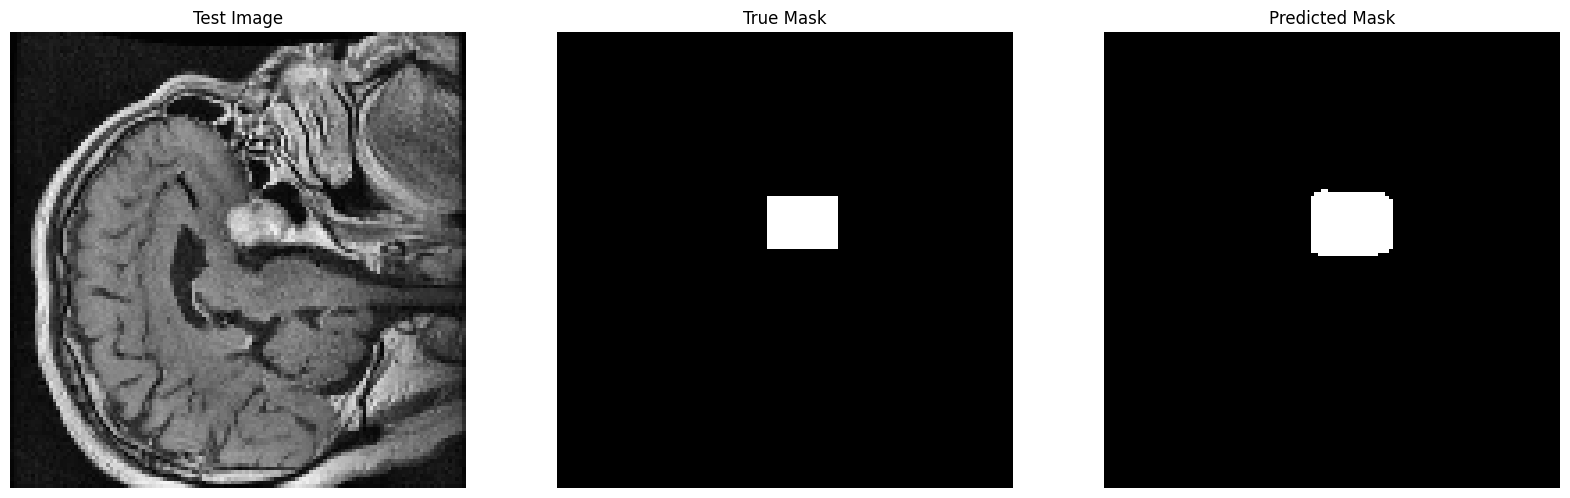

In [ ]:
# Function to display images
def display_images(images, titles=None, cmap=None):
    n = len(images)
    plt.figure(figsize=(20, 10))
    for i in range(n):
        plt.subplot(1, n, i + 1)
        plt.imshow(images[i], cmap=cmap)
        if titles:
            plt.title(titles[i])
        plt.axis('off')
    plt.show()

# Predict masks on the test set
UNetpredicted_masks = UNETmodel.predict(test_image)

# Threshold the predicted masks
UNetpredicted_masks = (UNetpredicted_masks > 0.5).astype(np.uint8)

# Display some test images with their true and predicted masks
num_images_to_display = 5
indices = np.random.choice(len(test_image), num_images_to_display, replace=False)

for i in indices:
    test_img = test_image[i]
    true_mask = test_mask[i].squeeze()
    predicted_mask = UNetpredicted_masks[i].squeeze()

    display_images(
        [test_img, true_mask, predicted_mask],
        titles=['Test Image', 'True Mask', 'Predicted Mask'],
        cmap='gray'
    )


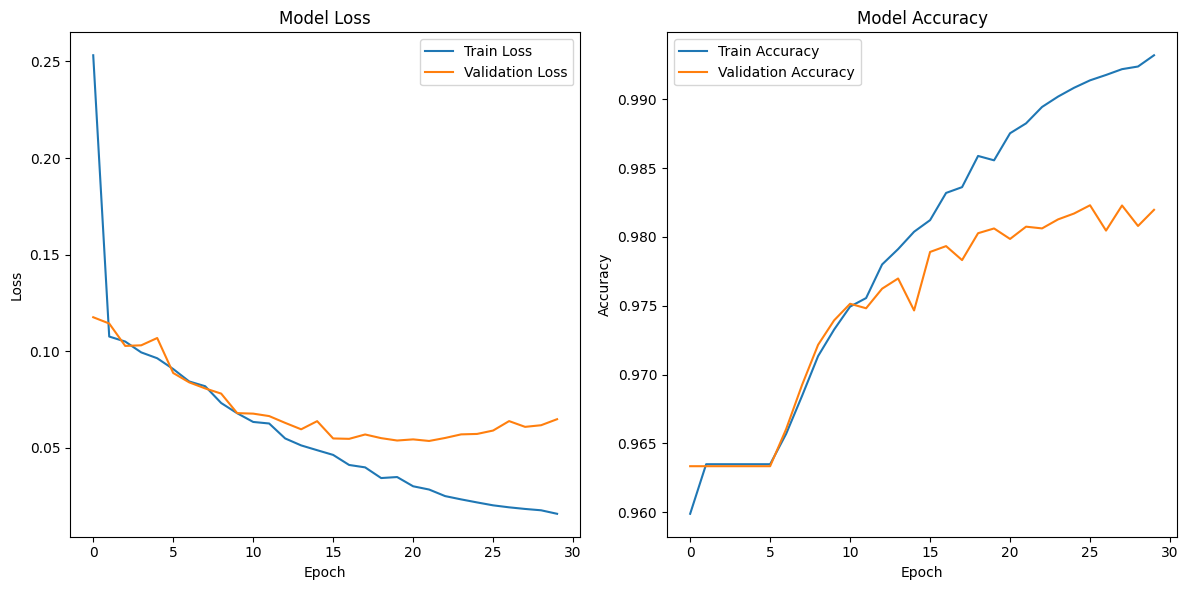

In [ ]:

#  Plot the loss graph
plt.figure(figsize=(12, 6))

# Plot training & validation loss values
plt.subplot(1, 2, 1)
plt.plot(UNethistory.history['loss'], label='Train Loss')
plt.plot(UNethistory.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')

#  Plot the accuracy graph
# Plot training & validation accuracy values
plt.subplot(1, 2, 2)
plt.plot(UNethistory.history['accuracy'], label='Train Accuracy')
plt.plot(UNethistory.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='upper left')

# Display the plots
plt.tight_layout()
plt.show()


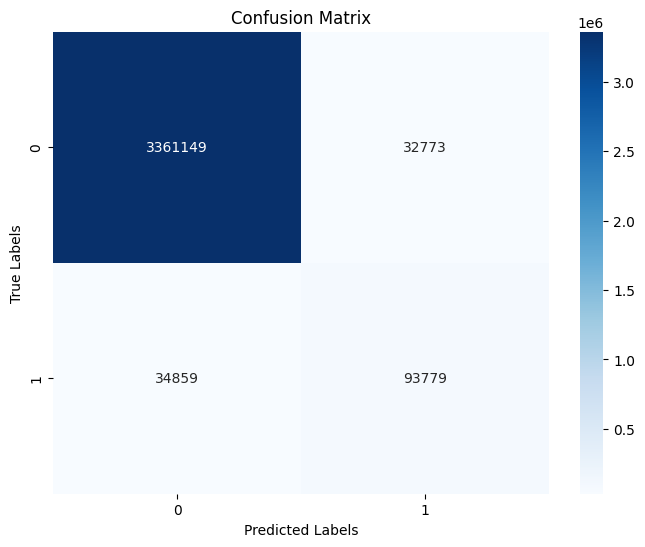

In [ ]:

# Flatten the true masks
y_true = test_mask.reshape(-1)  # Flatten to 1D array

# Flatten the predicted masks and apply threshold
y_pred = (UNetpredicted_masks > 0.5).astype(np.uint8).reshape(-1)  # Flatten to 1D array

# Check if the shapes match
if y_true.shape != y_pred.shape:
    raise ValueError(f"Shape mismatch: y_true has shape {y_true.shape}, but y_pred has shape {y_pred.shape}")

# Compute the confusion matrix
UNETconf_matrix = confusion_matrix(y_true, y_pred)

# Visualize the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(UNETconf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

In [ ]:

# Extract TP, FP, FN from the confusion matrix
TN, FP, FN, TP = UNETconf_matrix.ravel()

# Calculate precision and recall manually
precision = TP / (TP + FP)
recall = TP / (TP + FN)
f1 = f1_score(y_true, y_pred)

print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1 Score: {f1:.4f}')

Precision: 0.7410313547000442
Recall: 0.7290147545826272
F1 Score: 0.7350


In [ ]:
def conv2d_block(x, filters, kernel_size=3, padding='same', activation='relu'):
    x = layers.Conv2D(filters, kernel_size, padding=padding)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation(activation)(x)
    return x

def atrous_spatial_pyramid_pooling(x):
    # ASPP block
    b4 = layers.Conv2D(256, (1, 1), padding='same', activation='relu')(x)
    b4 = layers.BatchNormalization()(b4)

    b6 = layers.Conv2D(256, (3, 3), dilation_rate=(6, 6), padding='same', activation='relu')(x)
    b6 = layers.BatchNormalization()(b6)

    b12 = layers.Conv2D(256, (3, 3), dilation_rate=(12, 12), padding='same', activation='relu')(x)
    b12 = layers.BatchNormalization()(b12)

    b18 = layers.Conv2D(256, (3, 3), dilation_rate=(18, 18), padding='same', activation='relu')(x)
    b18 = layers.BatchNormalization()(b18)

    # Image pooling branch
    b_pool = layers.GlobalAveragePooling2D()(x)
    b_pool = layers.Reshape((1, 1, b_pool.shape[-1]))(b_pool)
    b_pool = layers.Conv2D(256, (1, 1), padding='same', activation='relu')(b_pool)
    b_pool = layers.BatchNormalization()(b_pool)
    b_pool = layers.UpSampling2D(size=(x.shape[1], x.shape[2]), interpolation='bilinear')(b_pool)

    # Concatenate all branches
    x = layers.Concatenate()([b4, b6, b12, b18, b_pool])
    x = layers.Conv2D(256, (1, 1), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    return x

def deeplabv3_model(input_shape, n_classes):
    inputs = tf.keras.Input(shape=input_shape)

    # Backbone: Xception
    backbone = tf.keras.applications.Xception(input_shape=input_shape, include_top=False, weights='imagenet')
    x = backbone(inputs, training=False)

    # ASPP
    x = atrous_spatial_pyramid_pooling(x)

    # Decoder: Upsampling to match input size
    x = layers.Conv2DTranspose(128, (3, 3), strides=(2, 2), padding='same', activation='relu')(x)
    x = conv2d_block(x, 128)

    x = layers.Conv2DTranspose(64, (3, 3), strides=(2, 2), padding='same', activation='relu')(x)
    x = conv2d_block(x, 64)

    # Final upsampling to exact size
    x = layers.Conv2DTranspose(n_classes, (16, 16), strides=(8, 8), padding='same')(x)
    outputs = layers.Activation('sigmoid')(x)

    model = models.Model(inputs, outputs)
    return model

In [ ]:
DeepLmodel = deeplabv3_model((128, 128, 3), 1)
DeepLmodel.summary()

83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1             │ (None, 128, 128, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ xception (Functional)     │ (None, 4, 4, 2048)     │     20,861,480 │ input_layer_1[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ global_average_pooling2d  │ (None, 2048)           │              0 │ xception[0][0]         │
│ (GlobalAveragePooling2D)  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ reshape (Reshape)         │ (None, 1, 1, 2048)     │              0 │ global_average_poolin… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_27 (Conv2D)        │ (None, 1, 1, 256)      │        524,544 │ reshape[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_23 (Conv2D)        │ (None, 4, 4, 256)      │        524,544 │ xception[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_24 (Conv2D)        │ (None, 4, 4, 256)      │      4,718,848 │ xception[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_25 (Conv2D)        │ (None, 4, 4, 256)      │      4,718,848 │ xception[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_26 (Conv2D)        │ (None, 4, 4, 256)      │      4,718,848 │ xception[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_8     │ (None, 1, 1, 256)      │          1,024 │ conv2d_27[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_4     │ (None, 4, 4, 256)      │          1,024 │ conv2d_23[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_5     │ (None, 4, 4, 256)      │          1,024 │ conv2d_24[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_6     │ (None, 4, 4, 256)      │          1,024 │ conv2d_25[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_7     │ (None, 4, 4, 256)      │          1,024 │ conv2d_26[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ up_sampling2d_4           │ (None, 4, 4, 256)      │              0 │ batch_normalization_8… │
│ (UpSampling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate_4        

 Total params: 36,971,689 (141.04 MB)

 Trainable params: 36,913,705 (140.81 MB)

 Non-trainable params: 57,984 (226.50 KB)

In [ ]:
# Define custom loss function
def dice_coefficient(y_true, y_pred, smooth=1):
    y_true_f = tf.keras.backend.flatten(y_true)
    y_pred_f = tf.keras.backend.flatten(y_pred)
    intersection = tf.keras.backend.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (tf.keras.backend.sum(y_true_f) + tf.keras.backend.sum(y_pred_f) + smooth)

def dice_loss(y_true, y_pred):
    return 1 - dice_coefficient(y_true, y_pred)

In [ ]:
# Compile the model
DeepLmodel.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=dice_loss,  # or 'categorical_crossentropy' for multi-class
    metrics=['accuracy', dice_coefficient]
)

In [ ]:
BATCH_SIZE = 16
EPOCHS = 50

DeepLhistory = DeepLmodel.fit(
    train_image, train_mask,
    validation_data=(val_image, val_mask),
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
        tf.keras.callbacks.ModelCheckpoint('deeplabv3_plus_best_model.keras', save_best_only=True)
    ]
)

Epoch 1/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 204s 1s/step - accuracy: 0.5134 - dice_coefficient: 0.0838 - loss: 0.9162 - val_accuracy: 0.7229 - val_dice_coefficient: 0.1040 - val_loss: 0.8960
Epoch 2/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 56s 331ms/step - accuracy: 0.7481 - dice_coefficient: 0.1253 - loss: 0.8747 - val_accuracy: 0.9150 - val_dice_coefficient: 0.1204 - val_loss: 0.8796
Epoch 3/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 40s 317ms/step - accuracy: 0.8396 - dice_coefficient: 0.1597 - loss: 0.8403 - val_accuracy: 0.9198 - val_dice_coefficient: 0.1618 - val_loss: 0.8381
Epoch 4/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 47s 379ms/step - accuracy: 0.8964 - dice_coefficient: 0.1995 - loss: 0.8005 - val_accuracy: 0.9283 - val_dice_coefficient: 0.2041 - val_loss: 0.7960
Epoch 5/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 34s 305ms/step - accuracy: 0.9309 - dice_coefficient: 0.2421 - loss: 0.7579 - val_accuracy: 0.9419 - val_dice_coefficient: 0.2474 - val_loss: 0.7527
Epoch 6/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 33s 355ms/step - accuracy: 0.

In [ ]:
#test_image, test_mask = preprocess_data(test_image, test_mask, target_size=(IMG_HEIGHT, IMG_WIDTH))
DeepLtest_loss, DeepLtest_accuracy, DeepLdice_loss = DeepLmodel.evaluate(test_image, test_mask, verbose=1)
print(f"Test Loss: {DeepLtest_loss}")
print(f"Test Accuracy: {DeepLtest_accuracy}")


7/7 ━━━━━━━━━━━━━━━━━━━━ 23s 2s/step - accuracy: 0.9821 - dice_coefficient: 0.7526 - loss: 0.2469
Test Loss: 0.24689790606498718
Test Accuracy: 0.9827951788902283


7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 575ms/step


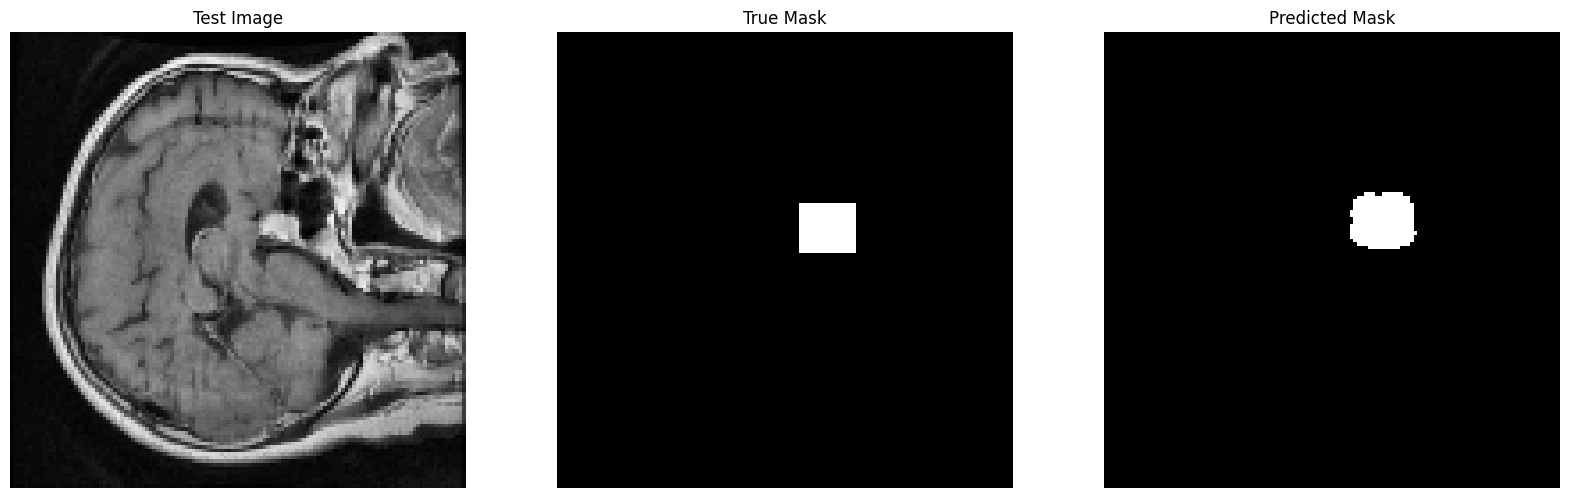

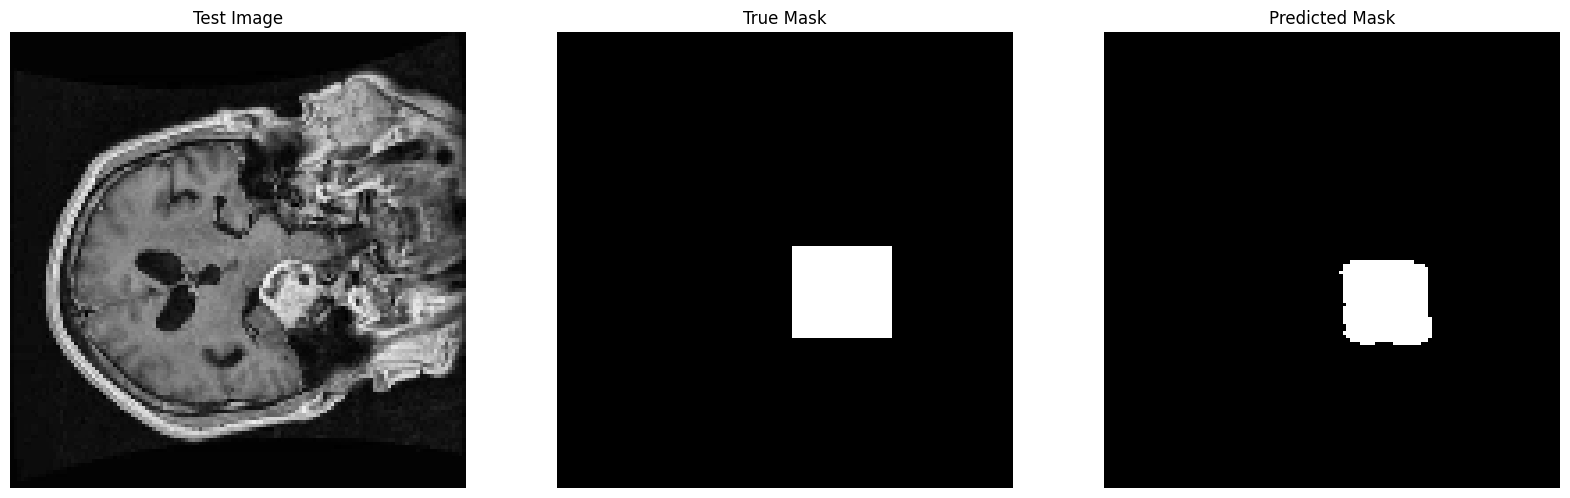

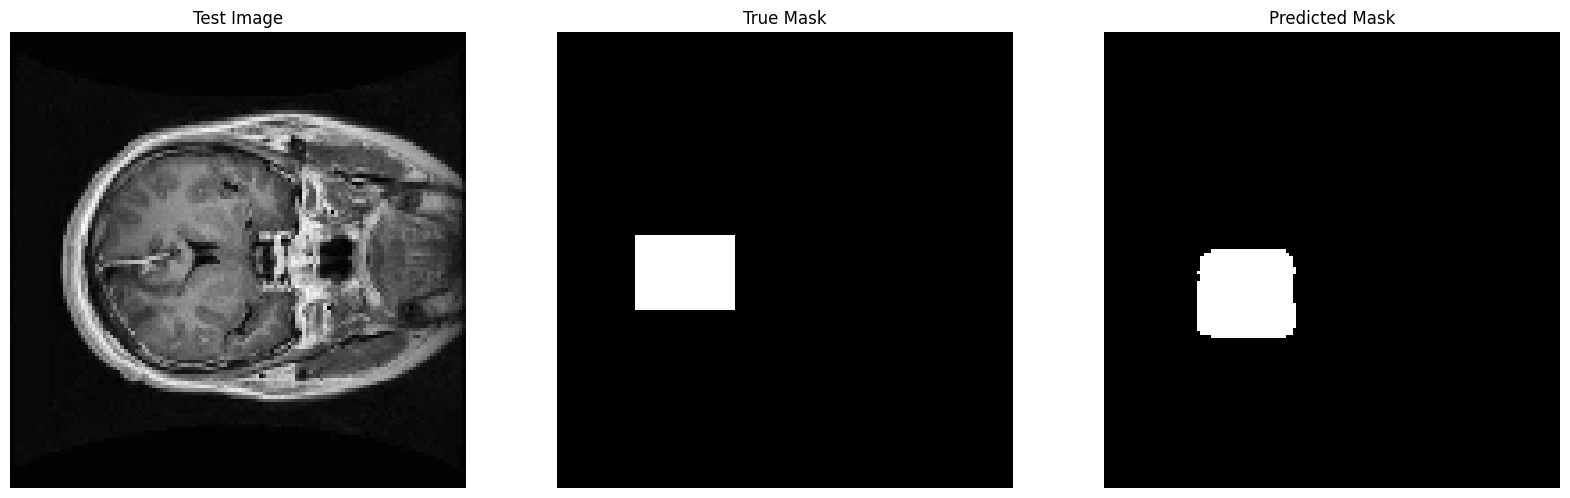

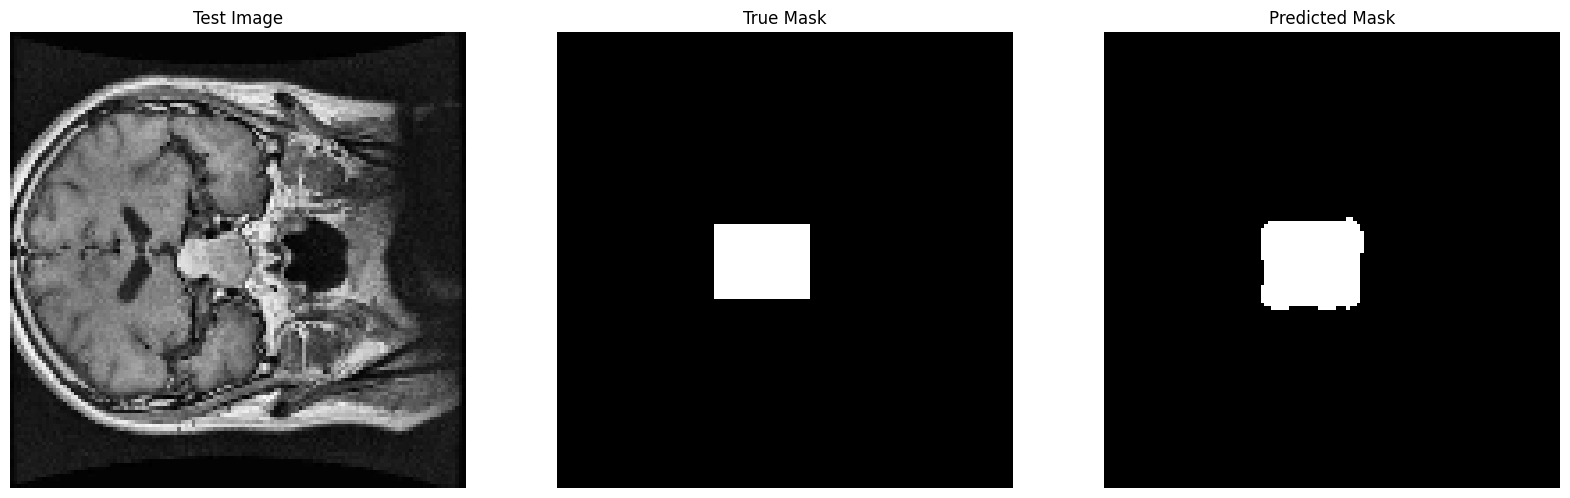

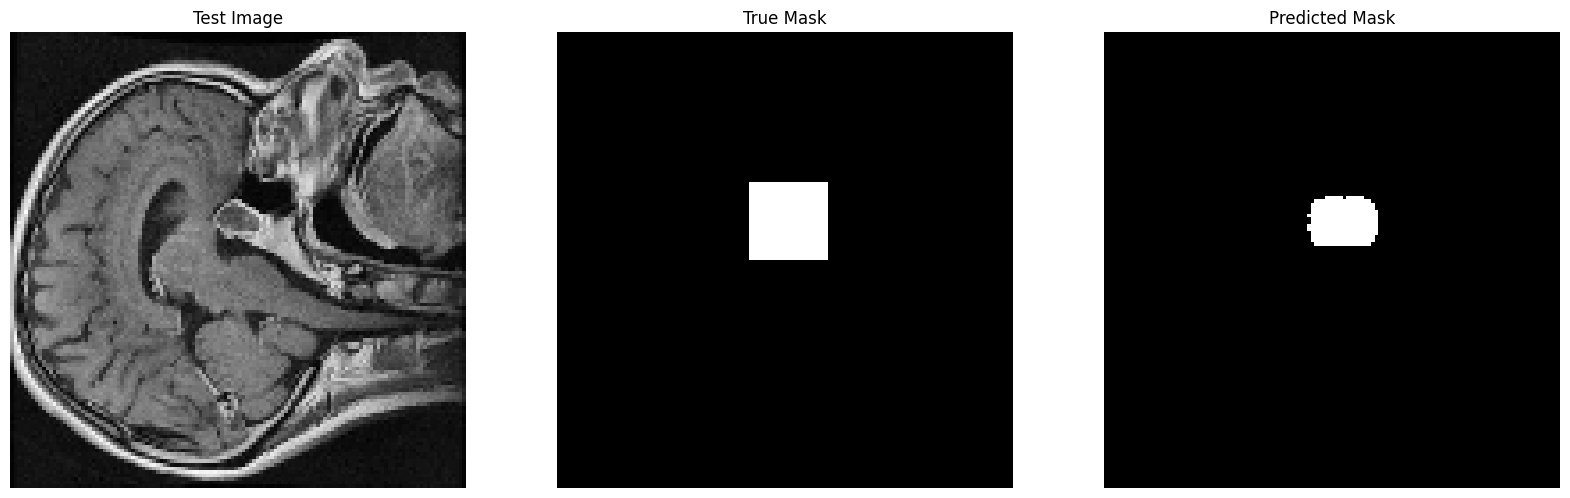

In [ ]:

# Function to display images
def display_images(images, titles=None, cmap=None):
    n = len(images)
    plt.figure(figsize=(20, 10))
    for i in range(n):
        plt.subplot(1, n, i + 1)
        plt.imshow(images[i], cmap=cmap)
        if titles:
            plt.title(titles[i])
        plt.axis('off')
    plt.show()

# Predict masks on the test set
DeepLpredicted_masks = DeepLmodel.predict(test_image)

# Apply a threshold to binarize the predicted masks
threshold = 0.5
binary_predicted_masks = (DeepLpredicted_masks > threshold).astype(np.uint8)

# Display some test images with their true and predicted masks
num_images_to_display = 5
indices = np.random.choice(len(test_image), num_images_to_display, replace=False)

for i in indices:
    test_img = test_image[i]
    true_mask = test_mask[i].squeeze()
    predicted_mask = binary_predicted_masks[i].squeeze()

    display_images(
        [test_img, true_mask, predicted_mask],
        titles=['Test Image', 'True Mask', 'Predicted Mask'],
        cmap='gray'
    )


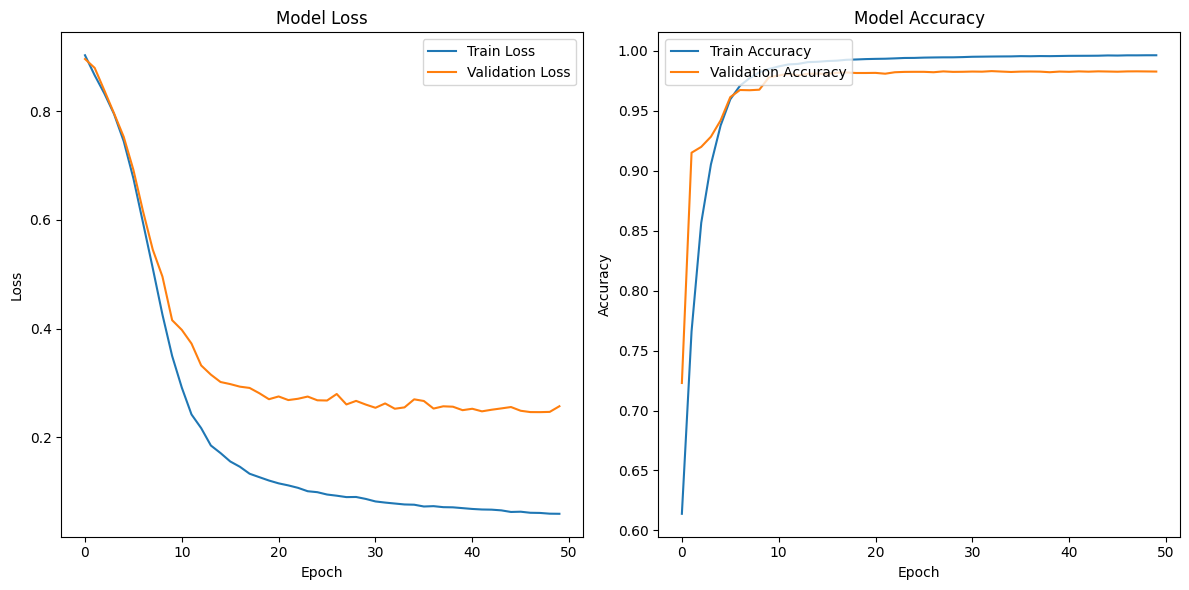

In [ ]:

#  Plot the loss graph
plt.figure(figsize=(12, 6))

# Plot training & validation loss values
plt.subplot(1, 2, 1)
plt.plot(DeepLhistory.history['loss'], label='Train Loss')
plt.plot(DeepLhistory.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')

#  Plot the accuracy graph
# Plot training & validation accuracy values
plt.subplot(1, 2, 2)
plt.plot(DeepLhistory.history['accuracy'], label='Train Accuracy')
plt.plot(DeepLhistory.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='upper left')

# Display the plots
plt.tight_layout()
plt.show()


Shape of y_true: (3522560,)
Shape of y_pred: (3522560,)


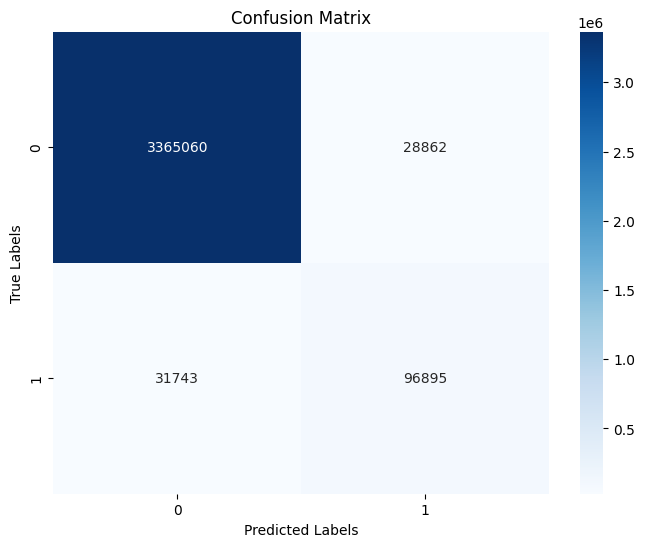

In [ ]:

# Flatten the true masks
y_true = test_mask.reshape(-1)  # Flatten to 1D array

# Flatten the predicted masks and apply threshold
y_pred = (DeepLpredicted_masks > 0.5).astype(np.uint8).reshape(-1)  # Flatten to 1D array

# Step 3: Debugging prints to check shapes
print(f"Shape of y_true: {y_true.shape}")
print(f"Shape of y_pred: {y_pred.shape}")

# Check if the shapes match
if y_true.shape != y_pred.shape:
    raise ValueError(f"Shape mismatch: y_true has shape {y_true.shape}, but y_pred has shape {y_pred.shape}")

# Compute the confusion matrix
DeepLconf_matrix = confusion_matrix(y_true, y_pred)

# Visualize the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(DeepLconf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

In [ ]:

# Extract TP, FP, FN from the confusion matrix
TN, FP, FN, TP = DeepLconf_matrix.ravel()

# Calculate precision and recall manually
precision = TP / (TP + FP)
recall = TP / (TP + FN)
f1 = f1_score(y_true, y_pred)

print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1 Score: {f1:.4f}')

Precision: 0.7704938890081665
Recall: 0.7532377680001244
F1 Score: 0.7618


In [ ]:

def fcn_model(input_shape):
    inputs = layers.Input(shape=input_shape)

    # Encoder: Convolutional layers with pooling
    conv1 = layers.Conv2D(64, (3, 3), padding='same', activation='relu')(inputs)
    conv1 = layers.Conv2D(64, (3, 3), padding='same', activation='relu')(conv1)
    pool1 = layers.MaxPooling2D((2, 2))(conv1)  # 256x256

    conv2 = layers.Conv2D(128, (3, 3), padding='same', activation='relu')(pool1)
    conv2 = layers.Conv2D(128, (3, 3), padding='same', activation='relu')(conv2)
    pool2 = layers.MaxPooling2D((2, 2))(conv2)  # 128x128

    conv3 = layers.Conv2D(256, (3, 3), padding='same', activation='relu')(pool2)
    conv3 = layers.Conv2D(256, (3, 3), padding='same', activation='relu')(conv3)
    pool3 = layers.MaxPooling2D((2, 2))(conv3)  # 64x64

    conv4 = layers.Conv2D(512, (3, 3), padding='same', activation='relu')(pool3)
    conv4 = layers.Conv2D(512, (3, 3), padding='same', activation='relu')(conv4)
    pool4 = layers.MaxPooling2D((2, 2))(conv4)  # 32x32

    conv5 = layers.Conv2D(1024, (3, 3), padding='same', activation='relu')(pool4)
    conv5 = layers.Conv2D(1024, (3, 3), padding='same', activation='relu')(conv5)  # 32x32

    # Upsampling and skip connections
    up6 = layers.Conv2DTranspose(512, (4, 4), strides=(2, 2), padding='same')(conv5)  # 64x64
    up6 = layers.add([up6, conv4])  # Combine with conv4 (64x64)

    up7 = layers.Conv2DTranspose(256, (4, 4), strides=(2, 2), padding='same')(up6)  # 128x128
    up7 = layers.add([up7, conv3])  # Combine with conv3 (128x128)

    up8 = layers.Conv2DTranspose(128, (4, 4), strides=(2, 2), padding='same')(up7)  # 256x256
    up8 = layers.add([up8, conv2])  # Combine with conv2 (256x256)

    up9 = layers.Conv2DTranspose(64, (4, 4), strides=(2, 2), padding='same')(up8)  # 512x512
    up9 = layers.add([up9, conv1])  # Combine with conv1 (512x512)

    # Final output layer
    outputs = layers.Conv2D(1, (1, 1), activation='sigmoid')(up9)

    # Create model
    model = models.Model(inputs, outputs)
    return model

# Example usage
input_shape = (128, 128, 3)
FCNmodel = fcn_model(input_shape)
FCNmodel.summary()


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7             │ (None, 128, 128, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_80 (Conv2D)        │ (None, 128, 128, 64)   │          1,792 │ input_layer_7[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_81 (Conv2D)        │ (None, 128, 128, 64)   │         36,928 │ conv2d_80[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_20          │ (None, 64, 64, 64)     │              0 │ conv2d_81[0][0]        │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_82 (Conv2D)        │ (None, 64, 64, 128)    │         73,856 │ max_pooling2d_20[0][0] │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_83 (Conv2D)        │ (None, 64, 64, 128)    │        147,584 │ conv2d_82[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_21          │ (None, 32, 32, 128)    │              0 │ conv2d_83[0][0]        │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_84 (Conv2D)        │ (None, 32, 32, 256)    │        295,168 │ max_pooling2d_21[0][0] │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_85 (Conv2D)        │ (None, 32, 32, 256)    │        590,080 │ conv2d_84[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_22          │ (None, 16, 16, 256)    │              0 │ conv2d_85[0][0]        │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_86 (Conv2D)        │ (None, 16, 16, 512)    │      1,180,160 │ max_pooling2d_22[0][0] │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_87 (Conv2D)        │ (None, 16, 16, 512)    │      2,359,808 │ conv2d_86[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_23          │ (None, 8, 8, 512)      │              0 │ conv2d_87[0][0]        │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_88 (Conv2D)        │ (None, 8, 8, 1024)     │      4,719,616 │ max_pooling2d_23[0][0] │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_89 (Conv2D)        │ (None, 8, 8, 1024)     │      9,438,208 │ conv2d_88[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_transpose_19       │ (None, 16, 16, 512)    │      8,389,120 │ conv2d_89[0][0]        │
│ (Conv2DTranspose)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add_24 (Add)         

 Total params: 29,985,345 (114.39 MB)

 Trainable params: 29,985,345 (114.39 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compile the model
FCNmodel.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy', dice_coefficient]
)

In [ ]:
FCNhistory = FCNmodel.fit(
    train_image, train_mask,
    steps_per_epoch=len(train_image) // BATCH_SIZE,
    validation_data=(val_image, val_mask),
    epochs=EPOCHS,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
        tf.keras.callbacks.ModelCheckpoint('FCN_best_model.keras', save_best_only=True)
    ]
)

Epoch 1/20
89/93 ━━━━━━━━━━━━━━━━━━━━ 1s 344ms/step - accuracy: 0.8981 - dice_coefficient: 0.0548 - loss: 0.3614

/usr/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


93/93 ━━━━━━━━━━━━━━━━━━━━ 85s 599ms/step - accuracy: 0.9003 - dice_coefficient: 0.0560 - loss: 0.3551 - val_accuracy: 0.9633 - val_dice_coefficient: 0.1453 - val_loss: 0.1142
Epoch 2/20
93/93 ━━━━━━━━━━━━━━━━━━━━ 33s 338ms/step - accuracy: 0.9644 - dice_coefficient: 0.1450 - loss: 0.1106 - val_accuracy: 0.9633 - val_dice_coefficient: 0.1670 - val_loss: 0.1141
Epoch 3/20
93/93 ━━━━━━━━━━━━━━━━━━━━ 33s 354ms/step - accuracy: 0.9632 - dice_coefficient: 0.1651 - loss: 0.1094 - val_accuracy: 0.9633 - val_dice_coefficient: 0.1749 - val_loss: 0.1074
Epoch 4/20
93/93 ━━━━━━━━━━━━━━━━━━━━ 29s 315ms/step - accuracy: 0.9641 - dice_coefficient: 0.1921 - loss: 0.1010 - val_accuracy: 0.9633 - val_dice_coefficient: 0.1827 - val_loss: 0.1052
Epoch 5/20
93/93 ━━━━━━━━━━━━━━━━━━━━ 43s 341ms/step - accuracy: 0.9641 - dice_coefficient: 0.2220 - loss: 0.0984 - val_accuracy: 0.9636 - val_dice_coefficient: 0.2091 - val_loss: 0.1020
Epoch 6/20
93/93 ━━━━━━━━━━━━━━━━━━━━ 30s 319ms/step - accuracy: 0.9649 - di

In [ ]:
#test_image, test_mask = preprocess_data(test_image, test_mask, target_size=(IMG_HEIGHT, IMG_WIDTH))
FCNtest_loss, FCNtest_accuracy, dice_loss = FCNmodel.evaluate(test_image, test_mask, verbose=1)
print(f"Test Loss: {FCNtest_loss}")
print(f"Test Accuracy: {FCNtest_accuracy}")


7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.9791 - dice_coefficient: 0.6538 - loss: 0.0552
Test Loss: 0.05528426170349121
Test Accuracy: 0.9789644479751587


7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 186ms/step


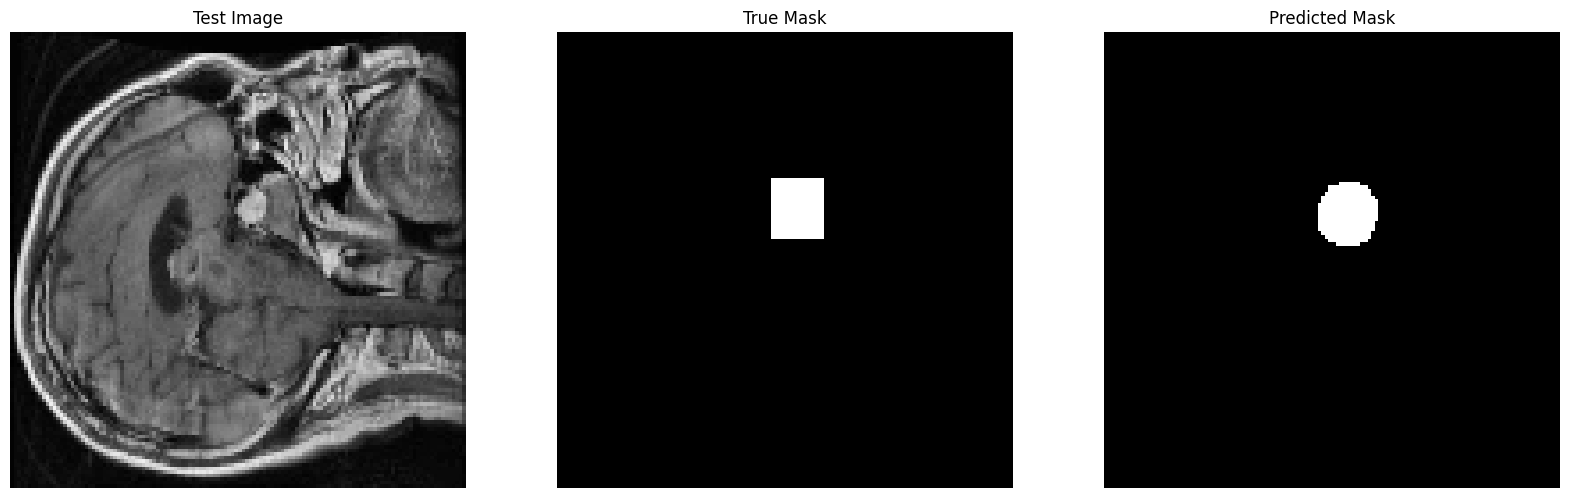

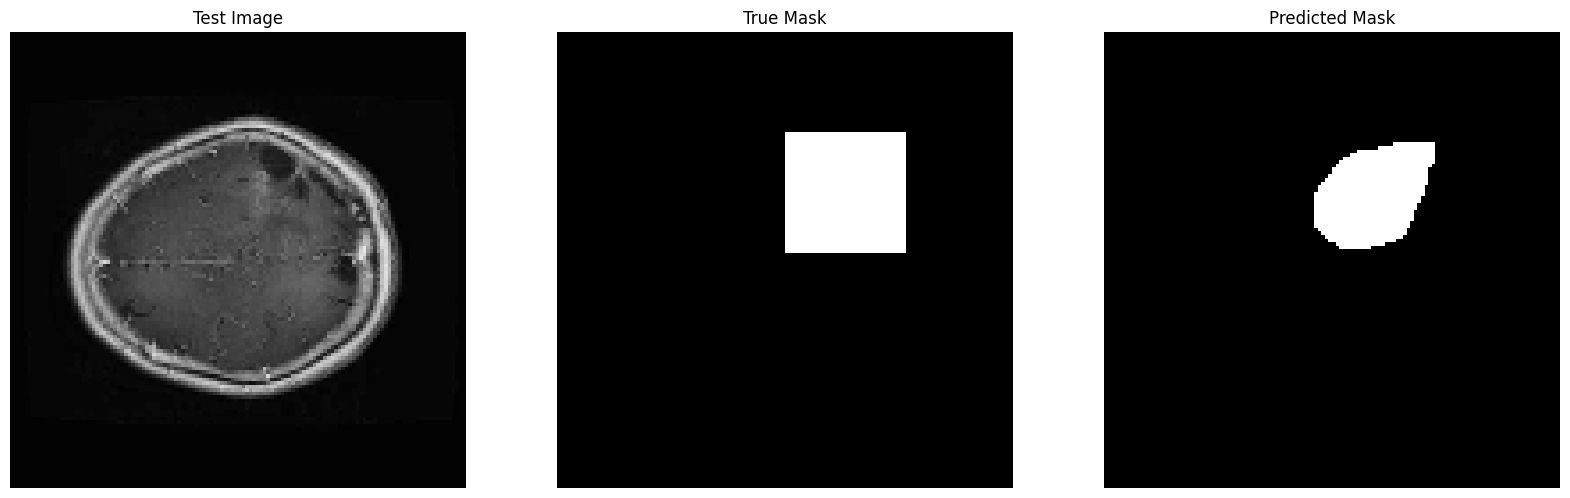

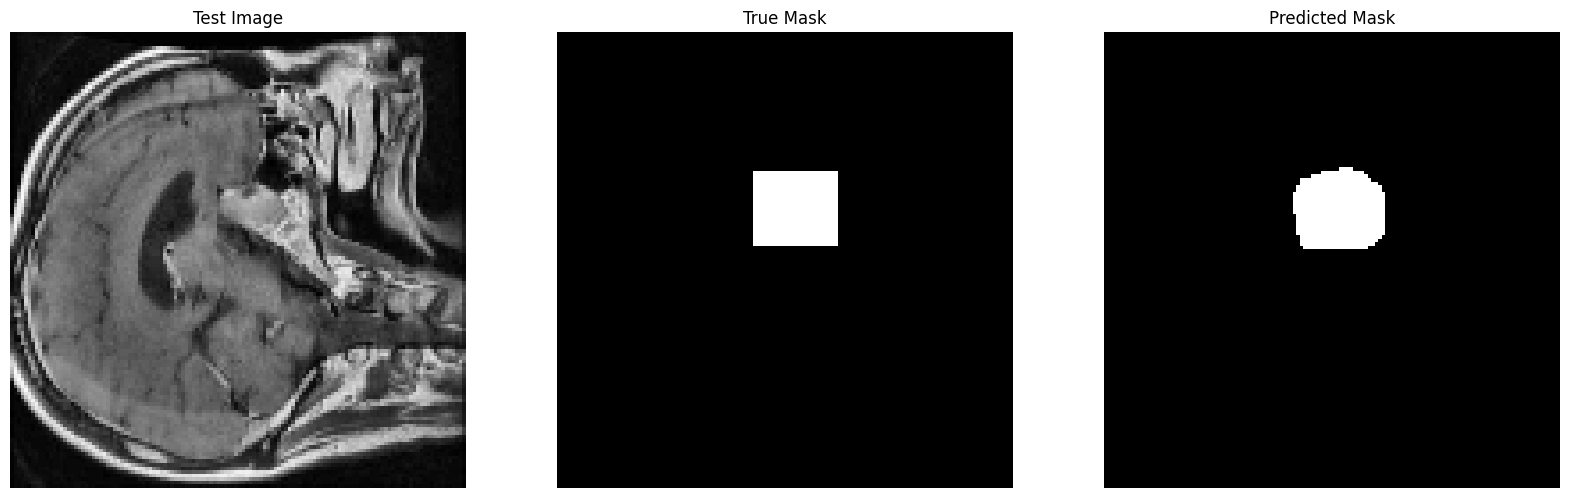

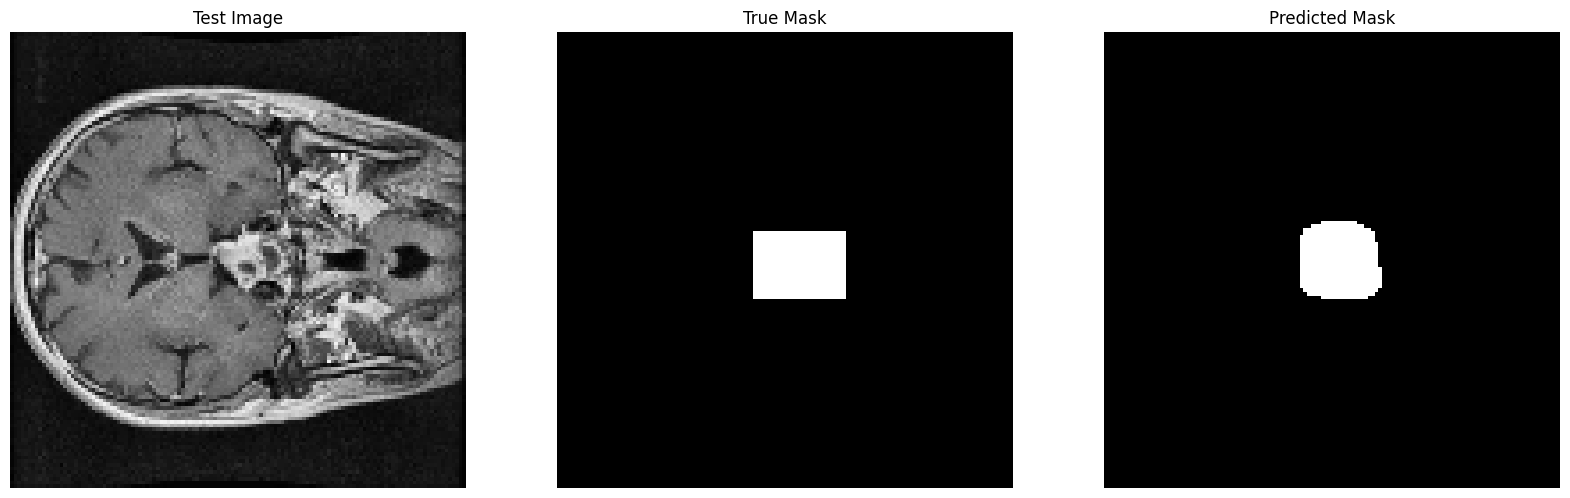

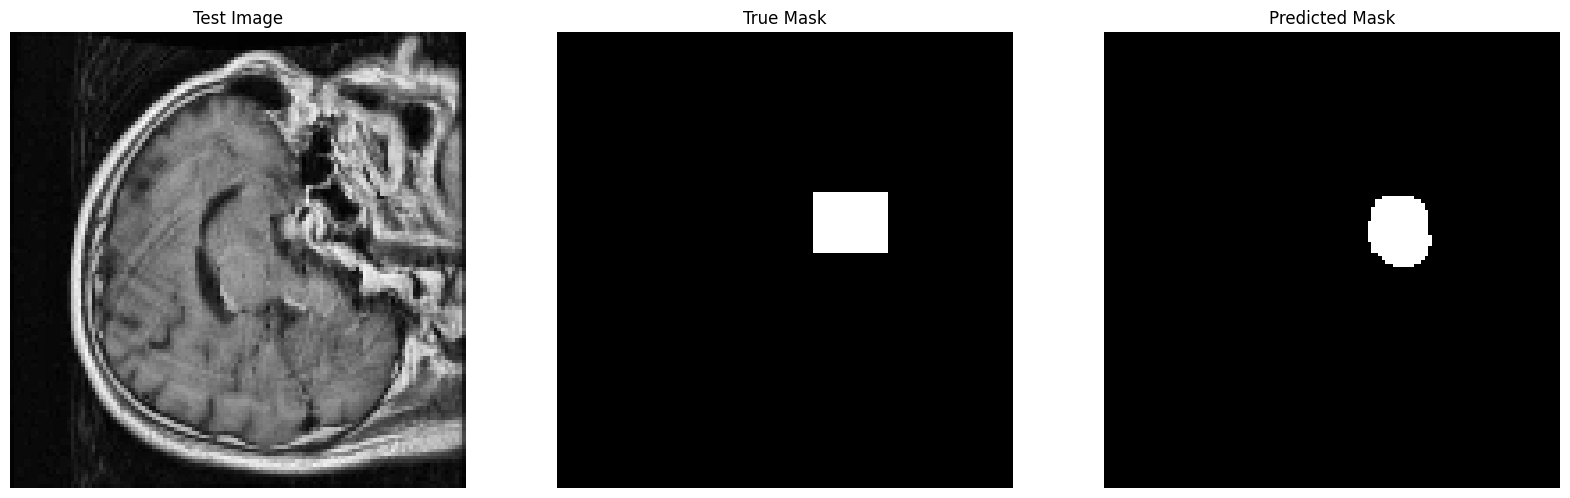

In [ ]:

# Function to display images
def display_images(images, titles=None, cmap=None):
    n = len(images)
    plt.figure(figsize=(20, 10))
    for i in range(n):
        plt.subplot(1, n, i + 1)
        plt.imshow(images[i], cmap=cmap)
        if titles:
            plt.title(titles[i])
        plt.axis('off')
    plt.show()

# Predict masks on the test set
FCNpredicted_masks = FCNmodel.predict(test_image)

# Apply a threshold to binarize the predicted masks
threshold = 0.5
binary_predicted_masks = (FCNpredicted_masks > threshold).astype(np.uint8)

# Display some test images with their true and predicted masks
num_images_to_display = 5
indices = np.random.choice(len(test_image), num_images_to_display, replace=False)

for i in indices:
    test_img = test_image[i]
    true_mask = test_mask[i].squeeze()
    predicted_mask = binary_predicted_masks[i].squeeze()

    display_images(
        [test_img, true_mask, predicted_mask],
        titles=['Test Image', 'True Mask', 'Predicted Mask'],
        cmap='gray'
    )


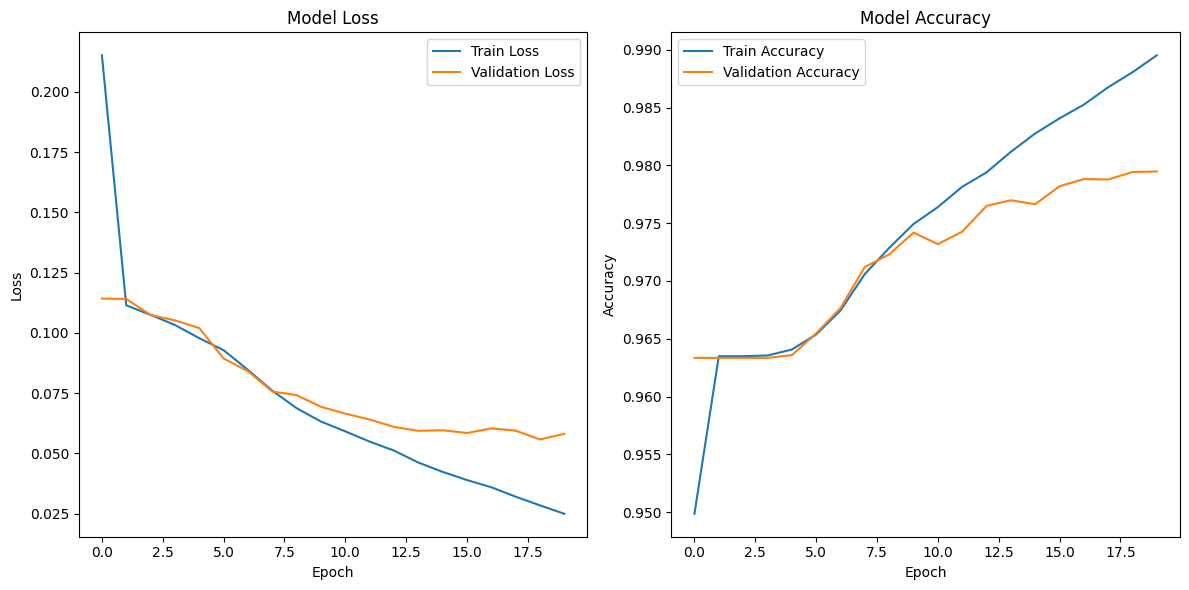

In [ ]:

#  Plot the loss graph
plt.figure(figsize=(12, 6))

# Plot training & validation loss values
plt.subplot(1, 2, 1)
plt.plot(FCNhistory.history['loss'], label='Train Loss')
plt.plot(FCNhistory.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')

#  Plot the accuracy graph
# Plot training & validation accuracy values
plt.subplot(1, 2, 2)
plt.plot(FCNhistory.history['accuracy'], label='Train Accuracy')
plt.plot(FCNhistory.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='upper left')

# Display the plots
plt.tight_layout()
plt.show()


7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step
Shape of y_true: (3522560,)
Shape of y_pred: (3522560,)


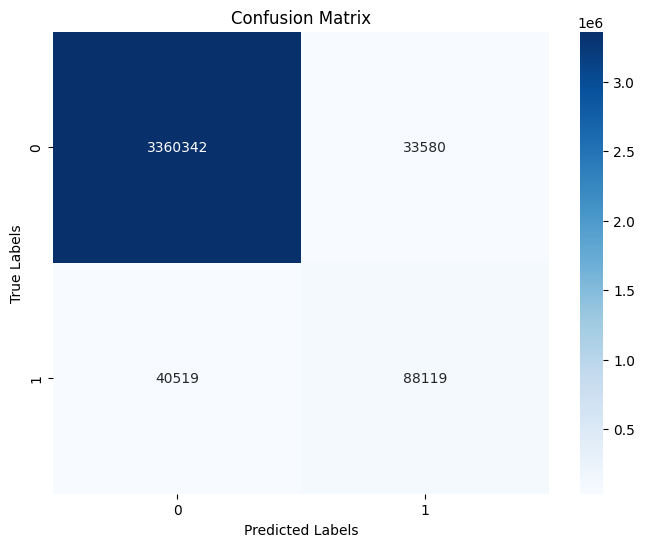

In [ ]:


FCNpredicted_masks = FCNmodel.predict(test_image)

#  Reshape y_true and y_pred to ensure they match
# Flatten the true masks
y_true = test_mask.reshape(-1)  # Flatten to 1D array

# Flatten the predicted masks and apply threshold
y_pred = (FCNpredicted_masks > 0.5).astype(np.uint8).reshape(-1)  # Flatten to 1D array

# Debugging prints to check shapes
print(f"Shape of y_true: {y_true.shape}")
print(f"Shape of y_pred: {y_pred.shape}")

# Check if the shapes match
if y_true.shape != y_pred.shape:
    raise ValueError(f"Shape mismatch: y_true has shape {y_true.shape}, but y_pred has shape {y_pred.shape}")

# Compute the confusion matrix
conf_matrix = confusion_matrix(y_true, y_pred)

#  Visualize the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

In [ ]:


# Assuming y_true and y_pred are already defined and correctly shaped
y_true = test_mask.reshape(-1)  # Flatten to 1D array
y_pred = (FCNpredicted_masks > 0.5).astype(np.uint8).reshape(-1)  # Flatten to 1D array

# Calculate confusion matrix
conf_matrix = confusion_matrix(y_true, y_pred)

# Extract TP, FP, FN from the confusion matrix
TN, FP, FN, TP = conf_matrix.ravel()

# Calculate precision and recall manually
precision = TP / (TP + FP)
recall = TP / (TP + FN)
f1 = f1_score(y_true, y_pred)

print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1 Score: {f1:.4f}')

Precision: 0.7240733284579166
Recall: 0.6850153142928217
F1 Score: 0.7040
